# Prendido: velocidad máxima en función del tiempo

Para cada medición `PRENDIDO_VS_ALTURA_*`:

1. En cada par se calcula el perfil `v_θ(r)` respecto del **centro seguido** (la partícula) y
   se toma su máximo: `v_max(t)`.
2. Se ajusta una recta a `v_max(t)` durante la subida.
3. Se grafica la pendiente de esa recta en función de la altura del agua.

In [2]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8")
fontsize = 25
plt.rcParams.update(
    {
        "font.family": "serif",
        "font.size": fontsize,
        "axes.labelsize": fontsize,
        "axes.titlesize": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fontsize": fontsize,
        "mathtext.default": "regular",
        "mathtext.fontset": "cm",
        "legend.frameon": True,
    }
)
AZUL, NARANJA = "#2A6FB5", "#E08A2E"

DATA = Path("../data glitter")
analisis = sorted(DATA.glob("*PRENDIDO_VS_ALTURA_*/*/parametros.json"))

## 1. Velocidad máxima de cada par

Los vectores medidos se agrupan en anillos de `ANCHO_ANILLO` alrededor del centro seguido de
ese par, se promedia `v_θ` en cada anillo y se toma el anillo con mayor `v_θ`. Los anillos más
cerca del centro que `R_MIN` tienen pocos vectores y se dejan afuera.

In [3]:
ANCHO_ANILLO = 0.25   # cm
R_MIN = 1.0           # cm
MIN_VECTORES = 5      # vectores por anillo y por par


def vmax_en_el_tiempo(p):
    P = json.loads(p.read_text(encoding="utf-8"))
    cam = P["camaras"]["A"]
    df = pd.read_csv(p.parent / cam["csv"], usecols=["frame", "x_mm", "y_mm", "u_mm_s", "v_mm_s", "valido"])
    df = df[df["valido"] == 1]
    centro = pd.read_csv(p.parent / cam["csv_centro"]).set_index("frame")

    c = centro.loc[df["frame"]]
    dx = (df["x_mm"].to_numpy() - c["xc_mm"].to_numpy()) / 10       # cm
    dy = (df["y_mm"].to_numpy() - c["yc_mm"].to_numpy()) / 10
    r = np.hypot(dx, dy)
    ok = r >= R_MIN
    vt = (df["v_mm_s"].to_numpy()[ok] * dx[ok] - df["u_mm_s"].to_numpy()[ok] * dy[ok]) / r[ok] / 10   # cm/s

    anillos = pd.DataFrame({"frame": df["frame"].to_numpy()[ok],
                            "anillo": np.floor(r[ok] / ANCHO_ANILLO),
                            "vt": vt})
    perfil = anillos.groupby(["frame", "anillo"])["vt"].agg(["mean", "size"])
    perfil = perfil[perfil["size"] >= MIN_VECTORES]
    vmax = perfil["mean"].groupby(level="frame").max()

    return dict(nombre=P["grabacion_info"]["nombre"],
                H=P["recipiente"]["altura_agua_mm"] / 10,             # cm
                V=P["recipiente"]["volumen_agua_ml"],
                t=centro.loc[vmax.index, "t_s"].to_numpy(),
                vmax=vmax.to_numpy())


mediciones = sorted((vmax_en_el_tiempo(p) for p in analisis), key=lambda m: m["H"])
for m in mediciones:
    print(f"{m['nombre']}:  H = {m['H']:.1f} cm,  V = {m['V']:.0f} ml,  {len(m['t'])} pares")

PRENDIDO_VS_ALTURA_1:  H = 5.0 cm,  V = 1200 ml,  1081 pares
PRENDIDO_VS_ALTURA_2:  H = 7.9 cm,  V = 1800 ml,  1080 pares
PRENDIDO_VS_ALTURA_3:  H = 9.1 cm,  V = 2400 ml,  1143 pares
PRENDIDO_VS_ALTURA_4:  H = 11.1 cm,  V = 3000 ml,  1201 pares
PRENDIDO_VS_ALTURA_5:  H = 12.7 cm,  V = 3600 ml,  2440 pares


## 2. Ajuste lineal de la subida

La recta se ajusta solo mientras la velocidad sube: entre que `v_max` (suavizada en
`SUAVIZADO_S`) pasa el `DESDE` y el `HASTA` del salto entre la velocidad inicial (primeros
3 s) y la final (últimos 10 s). La zona ajustada está sombreada.

Si en alguna medición la ventana automática no convence, se fija a mano en `VENTANA_MANUAL`
(en segundos).

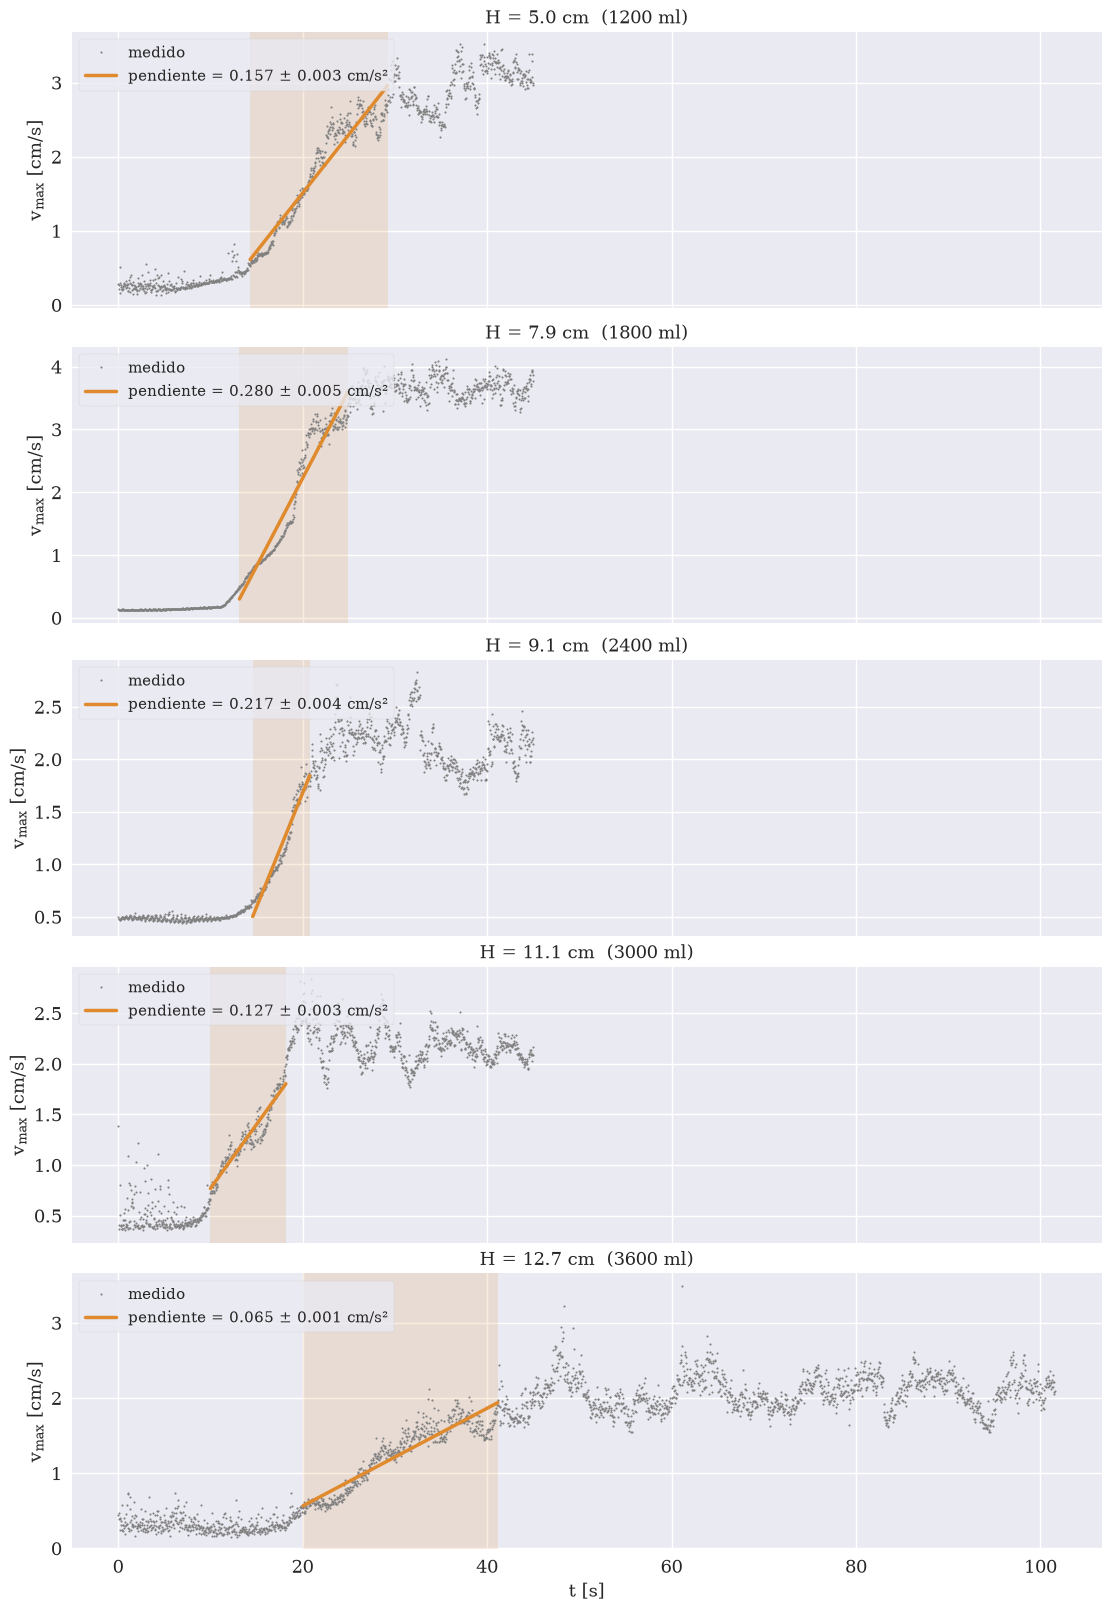

In [4]:
SUAVIZADO_S = 1.0
DESDE, HASTA = 0.1, 0.9
VENTANA_MANUAL = {}   # p.ej. {"PRENDIDO_VS_ALTURA_3": (11, 18)}


def ventana(m, clave="vmax"):
    if m["nombre"] in VENTANA_MANUAL:
        return VENTANA_MANUAL[m["nombre"]]
    t = m["t"]
    n = max(1, round(SUAVIZADO_S / np.median(np.diff(t))))
    suave = pd.Series(m[clave]).rolling(n, center=True, min_periods=1).mean().to_numpy()
    v_ini = suave[t < t[0] + 3].mean()
    v_fin = suave[t > t[-1] - 10].mean()
    t1 = t[np.argmax(suave > v_ini + DESDE * (v_fin - v_ini))]
    t2 = t[np.argmax((t > t1) & (suave > v_ini + HASTA * (v_fin - v_ini)))]
    return t1, t2


for m in mediciones:
    t1, t2 = ventana(m)
    sel = (m["t"] >= t1) & (m["t"] <= t2)
    (a, b), cov = np.polyfit(m["t"][sel], m["vmax"][sel], 1, cov=True)
    m.update(t1=t1, t2=t2, pendiente=a, err=np.sqrt(cov[0, 0]), ordenada=b)

fig, axs = plt.subplots(len(mediciones), 1, figsize=(11, 3.2 * len(mediciones)), sharex=True,
                        constrained_layout=True)
for ax, m in zip(np.atleast_1d(axs), mediciones):
    ax.plot(m["t"], m["vmax"], ".", ms=3, color="0.5", label="medido")
    ax.axvspan(m["t1"], m["t2"], color=NARANJA, alpha=0.15, lw=0)
    tt = np.array([m["t1"], m["t2"]])
    ax.plot(tt, m["pendiente"] * tt + m["ordenada"], lw=2.5, color=NARANJA,
            label=f"pendiente = {m['pendiente']:.3f} ± {m['err']:.3f} cm/s²")
    ax.set_ylabel(r"$v_{max}$ [cm/s]")
    ax.set_title(f"H = {m['H']:.1f} cm  ({m['V']:.0f} ml)")
    ax.legend(loc="upper left", fontsize=fontsize - 2)
ax.set_xlabel("t [s]")
plt.show()

## 3. Pendiente en función de la altura del agua

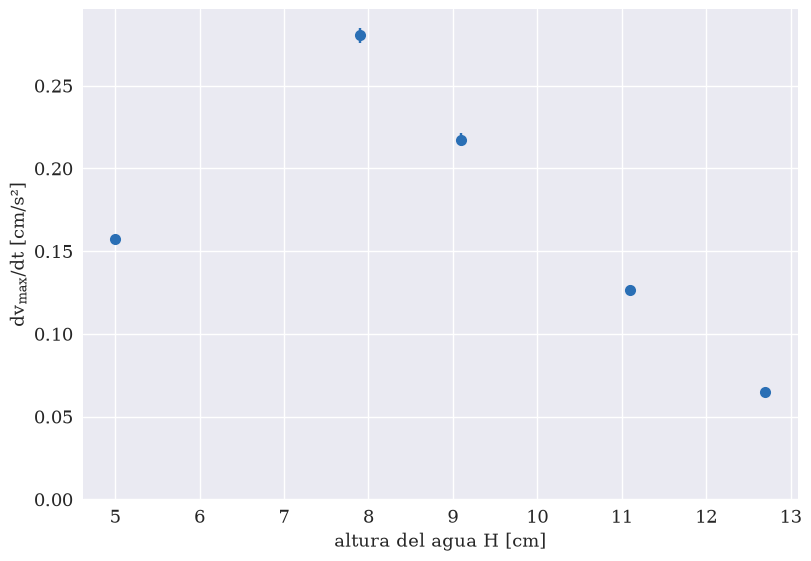

,H [cm],V [ml],ventana [s],pendiente [cm/s²],error [cm/s²]
PRENDIDO_VS_ALTURA_1,5.0,1200.0,14.3 a 29.2,0.1575,0.0026
PRENDIDO_VS_ALTURA_2,7.9,1800.0,13.2 a 24.9,0.2804,0.0047
PRENDIDO_VS_ALTURA_3,9.1,2400.0,14.6 a 20.8,0.2174,0.0041
PRENDIDO_VS_ALTURA_4,11.1,3000.0,10.0 a 18.2,0.1265,0.0027
PRENDIDO_VS_ALTURA_5,12.7,3600.0,20.1 a 41.2,0.0650,0.0012


In [5]:
H = np.array([m["H"] for m in mediciones])
pend = np.array([m["pendiente"] for m in mediciones])
err = np.array([m["err"] for m in mediciones])

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
ax.errorbar(H, pend, yerr=err, fmt="o", ms=8, capsize=4, color=AZUL)
ax.set_xlabel("altura del agua H [cm]")
ax.set_ylabel(r"$dv_{max}/dt$ [cm/s²]")
ax.set_ylim(bottom=0)
plt.show()

pd.DataFrame({
    "H [cm]": H,
    "V [ml]": [m["V"] for m in mediciones],
    "ventana [s]": [f"{m['t1']:.1f} a {m['t2']:.1f}" for m in mediciones],
    "pendiente [cm/s²]": pend.round(4),
    "error [cm/s²]": err.round(4),
}, index=[m["nombre"] for m in mediciones])

## 4. Lo mismo con la velocidad media

`v_media(t)`: el promedio de `v_θ` de todos los vectores medidos entre `R_MIN` y `R_MEDIA`
alrededor del centro seguido de cada par. `R_MEDIA` es **el mismo para todas las mediciones**, y
tiene que ser lo bastante chico para que, aunque el centro se mueva, ese círculo quede siempre
entero dentro de la región analizada (si no, en algunos pares faltaría el borde y la media
bajaría). La celda lo verifica. La ventana del ajuste se elige igual que para `v_max`.


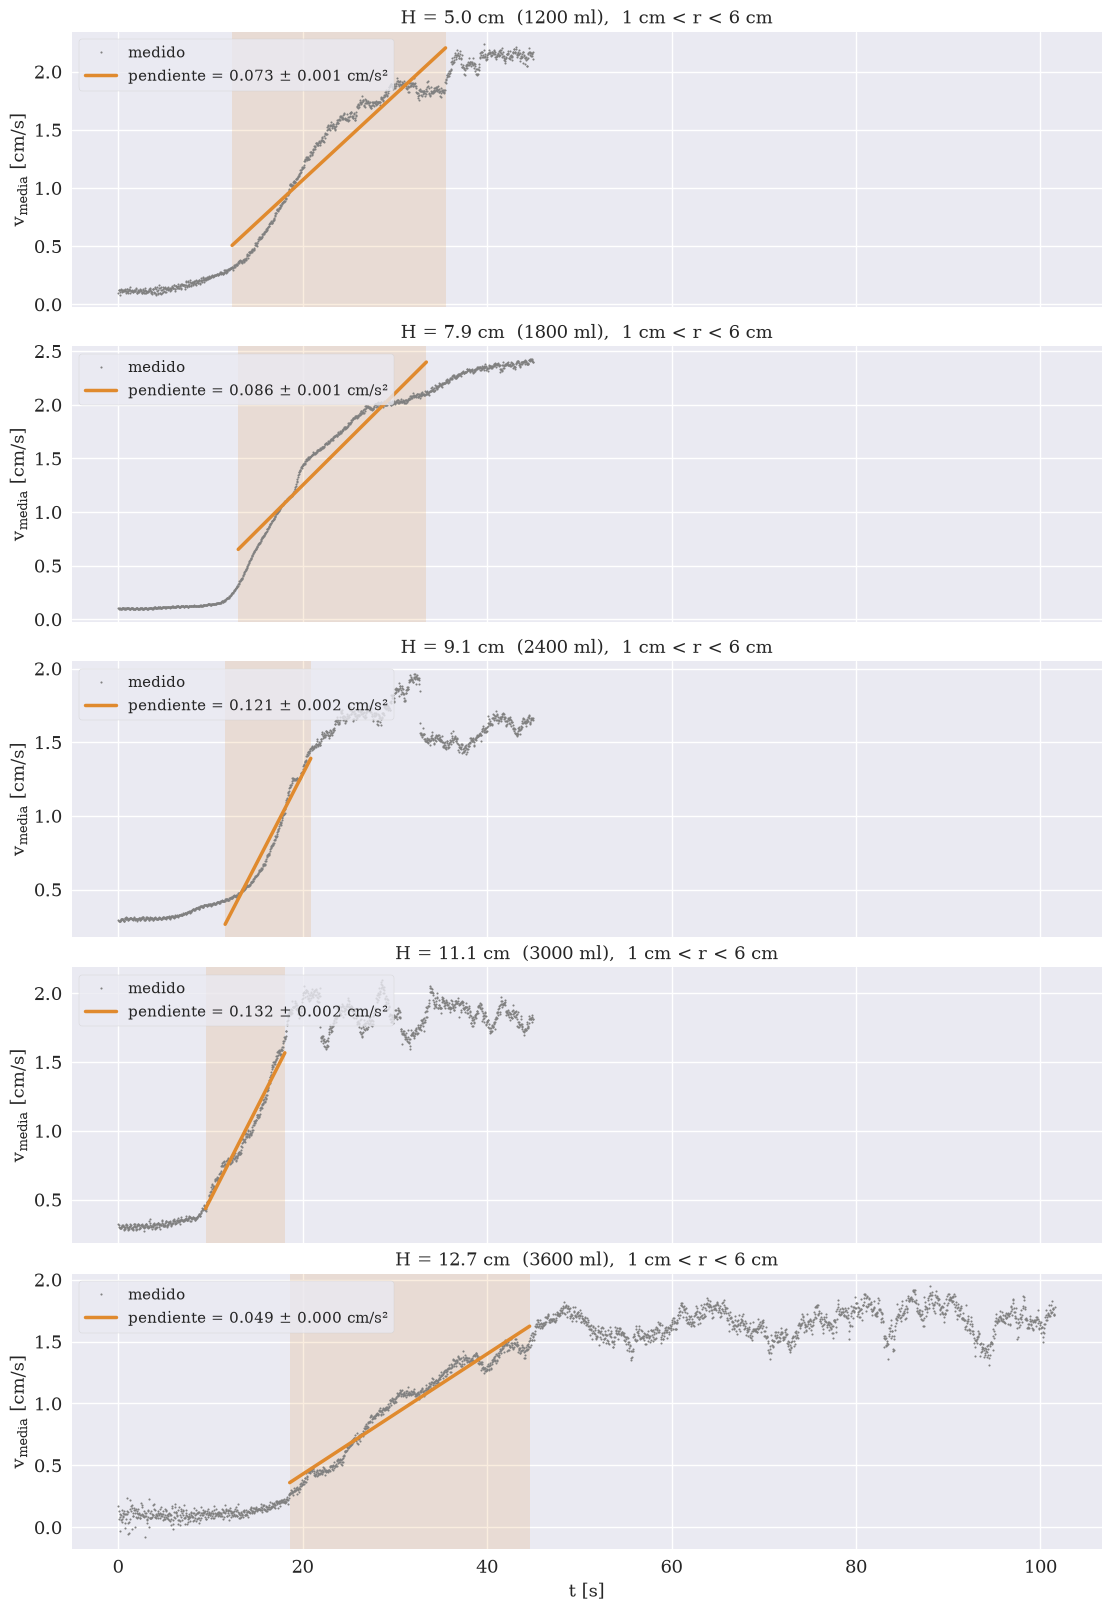

In [6]:
R_MEDIA = 6.0   # cm, el mismo en todas las mediciones


def vmedia_en_el_tiempo(p):
    P = json.loads(p.read_text(encoding="utf-8"))
    cam = P["camaras"]["A"]
    cal = cam["calibracion"]
    df = pd.read_csv(p.parent / cam["csv"], usecols=["frame", "x_mm", "y_mm", "u_mm_s", "v_mm_s", "valido"])
    df = df[df["valido"] == 1]
    centro = pd.read_csv(p.parent / cam["csv_centro"]).set_index("frame")

    # El círculo de radio R_MEDIA alrededor del centro seguido tiene que caer dentro de la región analizada
    s = cal["mm_por_px"] / 10                                         # cm/px
    cx, cy = np.array(cal["centro_vortice_px"]) * s
    alejamiento = np.hypot(centro["xc_mm"] / 10 - cx, centro["yc_mm"] / 10 - cy).max()
    libre = cal["radio_roi_px"] * s - alejamiento
    if R_MEDIA > libre:
        print(f"¡OJO! {P['grabacion_info']['nombre']}: el círculo de {R_MEDIA} cm se sale de la región "
              f"analizada en algunos pares (el máximo que entra siempre es {libre:.2f} cm)")

    c = centro.loc[df["frame"]]
    dx = (df["x_mm"].to_numpy() - c["xc_mm"].to_numpy()) / 10       # cm
    dy = (df["y_mm"].to_numpy() - c["yc_mm"].to_numpy()) / 10
    r = np.hypot(dx, dy)
    ok = (r >= R_MIN) & (r <= R_MEDIA)
    vt = (df["v_mm_s"].to_numpy()[ok] * dx[ok] - df["u_mm_s"].to_numpy()[ok] * dy[ok]) / r[ok] / 10   # cm/s
    vmedia = pd.Series(vt).groupby(df["frame"].to_numpy()[ok]).mean()

    return dict(nombre=P["grabacion_info"]["nombre"],
                H=P["recipiente"]["altura_agua_mm"] / 10,             # cm
                V=P["recipiente"]["volumen_agua_ml"],
                t=centro.loc[vmedia.index, "t_s"].to_numpy(),
                vmedia=vmedia.to_numpy())


mediciones_media = sorted((vmedia_en_el_tiempo(p) for p in analisis), key=lambda m: m["H"])
for m in mediciones_media:
    t1, t2 = ventana(m, "vmedia")
    sel = (m["t"] >= t1) & (m["t"] <= t2)
    (a, b), cov = np.polyfit(m["t"][sel], m["vmedia"][sel], 1, cov=True)
    m.update(t1=t1, t2=t2, pendiente=a, err=np.sqrt(cov[0, 0]), ordenada=b)

fig, axs = plt.subplots(len(mediciones_media), 1, figsize=(11, 3.2 * len(mediciones_media)), sharex=True,
                        constrained_layout=True)
for ax, m in zip(np.atleast_1d(axs), mediciones_media):
    ax.plot(m["t"], m["vmedia"], ".", ms=3, color="0.5", label="medido")
    ax.axvspan(m["t1"], m["t2"], color=NARANJA, alpha=0.15, lw=0)
    tt = np.array([m["t1"], m["t2"]])
    ax.plot(tt, m["pendiente"] * tt + m["ordenada"], lw=2.5, color=NARANJA,
            label=f"pendiente = {m['pendiente']:.3f} ± {m['err']:.3f} cm/s²")
    ax.set_ylabel(r"$v_{media}$ [cm/s]")
    ax.set_title(f"H = {m['H']:.1f} cm  ({m['V']:.0f} ml),  {R_MIN:g} cm < r < {R_MEDIA:g} cm")
    ax.legend(loc="upper left", fontsize=fontsize - 2)
ax.set_xlabel("t [s]")
plt.show()

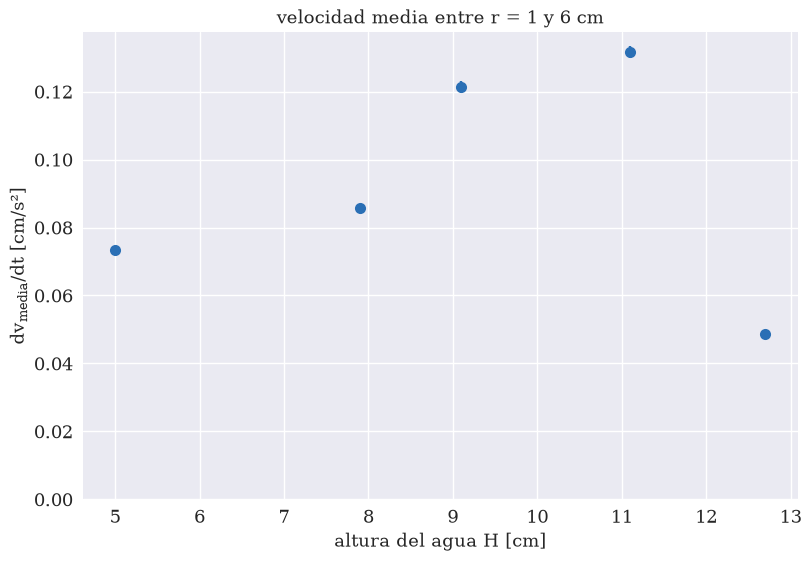

,H [cm],V [ml],ventana [s],pendiente [cm/s²],error [cm/s²]
PRENDIDO_VS_ALTURA_1,5.0,1200.0,12.4 a 35.5,0.0733,0.0011
PRENDIDO_VS_ALTURA_2,7.9,1800.0,13.0 a 33.4,0.0856,0.0012
PRENDIDO_VS_ALTURA_3,9.1,2400.0,11.6 a 20.9,0.1213,0.0018
PRENDIDO_VS_ALTURA_4,11.1,3000.0,9.5 a 18.1,0.1317,0.0017
PRENDIDO_VS_ALTURA_5,12.7,3600.0,18.6 a 44.6,0.0486,0.0005


In [7]:
H_media = np.array([m["H"] for m in mediciones_media])
pend_media = np.array([m["pendiente"] for m in mediciones_media])
err_media = np.array([m["err"] for m in mediciones_media])

fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
ax.errorbar(H_media, pend_media, yerr=err_media, fmt="o", ms=8, capsize=4, color=AZUL)
ax.set_xlabel("altura del agua H [cm]")
ax.set_ylabel(r"$dv_{media}/dt$ [cm/s²]")
ax.set_title(f"velocidad media entre r = {R_MIN:g} y {R_MEDIA:g} cm")
ax.set_ylim(bottom=0)
plt.show()

pd.DataFrame({
    "H [cm]": H_media,
    "V [ml]": [m["V"] for m in mediciones_media],
    "ventana [s]": [f"{m['t1']:.1f} a {m['t2']:.1f}" for m in mediciones_media],
    "pendiente [cm/s²]": pend_media.round(4),
    "error [cm/s²]": err_media.round(4),
}, index=[m["nombre"] for m in mediciones_media])